In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
with h5py.File(f"data/LCDB11_ER_eval.hdf5", "r") as f:
    data = f['error rate'][:]
    learner  = f['learner'][:]
print(f"The shape of database: {data.shape}")
print(f"The corresponding learner: {learner.shape}")

The shape of database: (1000, 137)
The corresponding learner: (1000, 1)


In [15]:
anchor_list = np.ceil(16 * 2 ** ((np.arange(137)) / 8)).astype(int)
print(f"The points along the curves are not linear but log scale in the list: \n {anchor_list}")
print("For example, the first point (anchor) is 16 training set size.")

The points along the curves are not linear but log scale in the list: 
 [     16      18      20      21      23      25      27      30      32
      35      39      42      46      50      54      59      64      70
      77      83      91      99     108     118     128     140     153
     166     182     198     216     235     256     280     305     332
     363     395     431     470     512     559     609     664     725
     790     862     940    1024    1117    1218    1328    1449    1580
    1723    1879    2048    2234    2436    2656    2897    3159    3445
    3757    4096    4467    4871    5312    5793    6317    6889    7513
    8192    8934    9742   10624   11586   12634   13778   15025   16384
   17867   19484   21248   23171   25268   27555   30049   32768   35734
   38968   42495   46341   50536   55109   60097   65536   71468   77936
   84990   92682  101071  110218  120194  131072  142936  155872  169980
  185364  202141  220436  240388  262144  285871  31

### Visualization

Sample index 11053, Learner label 3


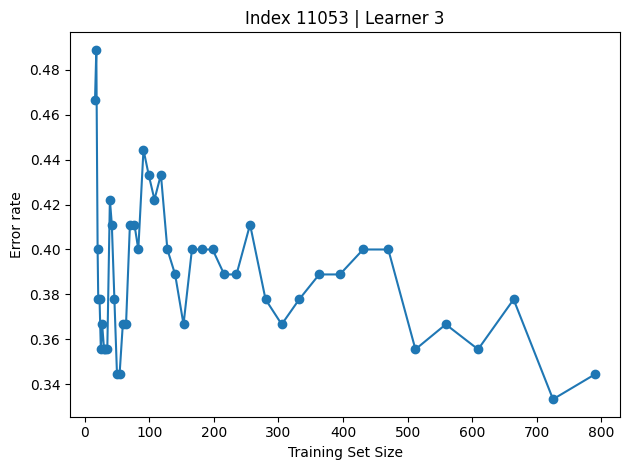

In [16]:
rng = np.random.default_rng()

# random sample index within range
idx = rng.integers(0, data.shape[0])
print(f"Sample index {idx}, Learner label {learner[idx, 0]}")

# get one curve 
curve = data[idx, :]

# mask NaN values
valid_mask = ~np.isnan(curve)
curve_valid = curve[valid_mask]

x = anchor_list[:len(curve_valid)]

plt.figure()
plt.plot(x, curve_valid, marker="o")
plt.xlabel("Training Set Size")
plt.ylabel("Error rate")
plt.title(f"Index {idx} | Learner {learner[idx, 0]}")
plt.tight_layout()
plt.show()

### submission format

In [17]:
with h5py.File(f"data_kaggle/LCDB11_ER_eval.hdf5", "r") as f:
    data = f['error rate'][:]
print(f"The shape of database: {data.shape}")


The shape of database: (1000, 137)


In [ ]:
n_rows = data.shape[0]   
n_bins = 1000

# uniform distribution prediction
pred = np.full((n_rows, n_bins), 1.0 / n_bins, dtype=np.float32)

print(pred.shape)                 
print(pred.sum(axis=1)[:5])       

df = pd.DataFrame(pred, columns=[f"bin_{i}" for i in range(n_bins)])
df.insert(0, "id", np.arange(n_rows))

df.to_csv("example_submission.csv", index=False)

(1000, 1000)
[1.0000001 1.0000001 1.0000001 1.0000001 1.0000001]
